In [1]:
%load_ext autoreload
%autoreload 2

### 1. Khởi tạo môi trường và đường dẫn

In [2]:
import os
import torch

CAPTIONS_PATH = "../data/flickr8k/captions.txt"
IMAGES_DIR = "../data/flickr8k/Images"
PREDICT_DIR = "Predict"
SAVE_PATH = "best_model_network1.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


### 2. Chuẩn bị DataLoader và Hiển thị thống kê

In [3]:
from src.model.advanced import *

BATCH_SIZE = 16
IMAGE_SIZE = 224
MAX_LEN = 24
MIN_FREQ = 1
NUM_WORKERS = 0

train_loader, val_loader, vocab, captions_df = get_dataloaders(
    IMAGES_DIR, CAPTIONS_PATH, BATCH_SIZE, IMAGE_SIZE, MAX_LEN, MIN_FREQ, NUM_WORKERS
)

idx2token = {idx: token for token, idx in vocab.items()}
print("Kích thước bộ từ vựng (Vocab size):", len(vocab))


Kích thước bộ từ vựng (Vocab size): 8832


### 3. Trực quan hóa dữ liệu (Visualize Sample)

Sample image: 1000268201_693b08cb0e.jpg
Num captions for sample: 5
Captions:
-  A child in a pink dress is climbing up a set of stairs in an entry way .
-  A girl going into a wooden building .
-  A little girl climbing into a wooden playhouse .


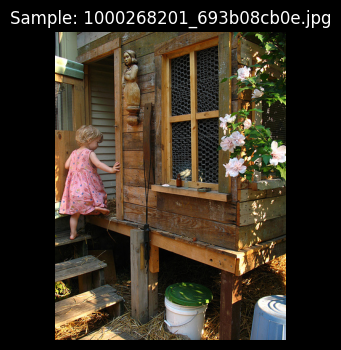

In [4]:
visualize_dataset_sample(IMAGES_DIR, captions_df)

### 4. Định nghĩa Hyperparameters và Khởi tạo Model (Network1)

In [5]:
# --- H Y P E R P A R A M E T E R S ---
LEARNING_RATE = 1e-3
EPOCHS = 20

pad_id = vocab["<PAD>"]

print("Khởi tạo Network 1 (ResNet18 + Attention + LSTM)")
model = ImageCaptioningModel(
    vocab_size=len(vocab),
    pad_idx=pad_id,
    embed_dim=512,
    hidden_dim=512,
    feature_dim=512,
    attn_dim=512
).to(DEVICE)

criterion = torch.nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

Khởi tạo Network 1 (ResNet18 + Attention + LSTM)


### 5. Huấn luyện (Training)

In [ ]:
best_loss = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    epochs=EPOCHS,
    save_path=SAVE_PATH
)


Epoch 01/20


-> train_loss=4.7214 | val_loss=4.0563
🌟 Val loss improved from inf to 4.0563. Saving model...

Epoch 02/20


-> train_loss=3.9721 | val_loss=3.7381
🌟 Val loss improved from 4.0563 to 3.7381. Saving model...

Epoch 03/20


-> train_loss=3.7702 | val_loss=3.5497
🌟 Val loss improved from 3.7381 to 3.5497. Saving model...

Epoch 04/20


Training:  88%|████████▊ | 399/456 [01:03<00:10,  5.58it/s, loss=3.59]

### 6. Đánh giá mô hình bằng BLEU Score

In [ ]:
if os.path.exists(SAVE_PATH):
    model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True), strict=False)
    print("Đã tải trọng số mô hình tốt nhất để tính BLEU.")

bleu1, bleu2, bleu3, bleu4 = calculate_bleu_score(
    model=model,
    val_loader=val_loader,
    vocab=vocab,
    idx2token=idx2token,
    decode_ids_fn=decode_ids,
    device=DEVICE,
    max_len=MAX_LEN,
    num_batches=None # Tính trên toàn bộ tập Validation
)

### 7. Dự đoán trên tập ảnh tự do (Prediction)

In [ ]:
if os.path.exists(SAVE_PATH):
    model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True), strict=False)

if not os.path.exists(PREDICT_DIR):
    os.makedirs(PREDICT_DIR)
    print(f"Đã tạo thư mục {PREDICT_DIR}. Vui lòng thêm ảnh vào thư mục này để thực hiện dự đoán.")
else:
    predict_folder(
        model=model,
        folder_path=PREDICT_DIR,
        vocab=vocab,
        decode_ids_fn=decode_ids,
        idx2token=idx2token,
        device=DEVICE,
        image_size=IMAGE_SIZE,
        max_len=MAX_LEN
    )